In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_openai import ChatOpenAI
llm_gpt = ChatOpenAI(model='gpt-4o', temperature=0)

/Users/shudhanshu/Desktop/Study Projects/GenAI/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [90]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langchain_core.prompts import ChatPromptTemplate

from langchain_core.output_parsers import PydanticOutputParser, JsonOutputParser,StrOutputParser

In [91]:
from langgraph.graph import StateGraph, START, END

In [92]:
class State(TypedDict):
    messages: Annotated[list,add_messages]

In [93]:
import requests
from langchain_core.tools import tool

In [94]:
@tool
def get_weather(query:str)->list:
    """Search weatherapi to get the current weather."""
    base_url = "https://api.openweathermap.org/data/2.5/weather"
    complete_url = f"{base_url}?q={query}&APPID={os.environ.get('WEATHER_API_KEY')}"

    response = requests.get(complete_url)
    data = response.json()

    print(complete_url)
    print(data)
    if data.get('name'):
        return data
    else:
        return "weather data not found"

# @tool
# def format_output(input_data:dict):
#     """Function that will take input and return english redable statement after analysing the input"""
#     prompt = ChatPromptTemplate.from_template(
#         """
#         Act as assistant and analyse below information to make it human redable in english.

#         Information:
#         {information}
#         """
#     )
#     llm_chain = (
#         prompt
#         |
#         llm_gpt
#         |
#         StrOutputParser()
#     )

#     return llm_chain.invoke({"information":input_data})


In [95]:
tools = [
    get_weather, 
    # format_output
]
tools

[StructuredTool(name='get_weather', description='Search weatherapi to get the current weather.', args_schema=<class 'langchain_core.utils.pydantic.get_weather'>, func=<function get_weather at 0x132256480>)]

In [96]:
llm_with_tools=llm_gpt.bind_tools(tools=tools)

In [97]:
llm_with_tools.invoke("what is current weather in varanasi")

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 54, 'total_tokens': 70, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_64cfb65ad0', 'id': 'chatcmpl-DYT8WFigSwEc6s7dDA84CSLGS672q', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019dc3dc-db30-7db1-96ec-1cf2b413ec42-0', tool_calls=[{'name': 'get_weather', 'args': {'query': 'Varanasi'}, 'id': 'call_58bbQArtI4qCBE1lzVM6ECVQ', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 54, 'output_tokens': 16, 'total_tokens': 70, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [98]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

In [108]:
#Augument LLM with tools node function

def tool_calling_llm(state:State)->State:
    current_state = state['messages']
    return {"messages":[llm_with_tools.invoke(current_state)]}

# from langchain_core.messages import SystemMessage

# def tool_calling_llm(state: State) -> State:
#     current_messages = state['messages']
    
#     # Check if we have a system message; if not, add one to force 'English'
#     if not any(isinstance(m, SystemMessage) for m in current_messages):
#         instructions = SystemMessage(content="You are a helpful assistant. Summarize tool results clearly in natural English.")
#         current_messages = [instructions] + current_messages
        
#     # Invoke the LLM
#     response = llm_with_tools.invoke(current_messages)
    
#     return {"messages": [response]}

In [109]:
# Build the graph

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools=tools))
builder.add_edge(START, "tool_calling_llm")


# conditional_edge
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition,
    ["tools", END]
)

builder.add_edge("tools", "tool_calling_llm") #this is the key feedback loop

# builder.add_edge("tools", END) # conflicting line

agent = builder.compile()

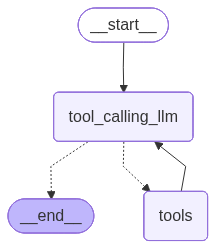

In [110]:
agent

In [111]:

for event in graph.stream({"messages":"Explain AI in 2 bullet points to a child"}, stream_mode='values'):
    print(event['messages'][-1].pretty_print()
         )


================================ Human Message =================================

Explain AI in 2 bullet points to a child
None
================================== Ai Message ==================================

- **AI is like a super-smart robot brain:** Imagine a robot that can learn and think like a human. It can play games, answer questions, and even help with homework by understanding and solving problems.

- **AI helps make things easier and more fun:** It can help you find your favorite cartoons, suggest new games to play, or even talk to you like a friend, making everyday tasks more exciting and enjoyable.
None


In [115]:
for event in graph.stream({"messages":"what is current weather of delhi, explain in simple english"}, stream_mode='values'):
    print(event['messages'][-1]
         )

content='what is current weather of delhi, explain in simple english' additional_kwargs={} response_metadata={} id='cb010fd9-e74f-455e-ba2d-b3b5b4ffe9ff'
content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 58, 'total_tokens': 72, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_64cfb65ad0', 'id': 'chatcmpl-DYTJ24Z0Ok47N4nPh6wT7IJztcmMq', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019dc3e6-ca87-7aa3-b209-d801facdf2aa-0' tool_calls=[{'name': 'get_weather', 'args': {'query': 'Delhi'}, 'id': 'call_CaIe1Fkj2SMbvQ7Vdr2DWiaY', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 58, 'output_tokens': 14, 'total_tok

In [117]:
from IPython.display import display, Markdown
print(event['messages'][-1].pretty_print())

================================= Tool Message =================================
Name: get_weather

{"coord": {"lon": 77.2167, "lat": 28.6667}, "weather": [{"id": 802, "main": "Clouds", "description": "scattered clouds", "icon": "03d"}], "base": "stations", "main": {"temp": 315.2, "feels_like": 313.68, "temp_min": 315.2, "temp_max": 315.2, "pressure": 1003, "humidity": 15, "sea_level": 1003, "grnd_level": 978}, "visibility": 6000, "wind": {"speed": 3.09, "deg": 290, "gust": 8.23}, "clouds": {"all": 40}, "dt": 1777108126, "sys": {"type": 1, "id": 9165, "country": "IN", "sunrise": 1777076151, "sunset": 1777123329}, "timezone": 19800, "id": 1273294, "name": "Delhi", "cod": 200}
None


In [114]:
inputs = {"messages": [("user", "what is current weather of delhi, explain in simple english")]}

for event in agent.stream(inputs, stream_mode='values'):
    message = event['messages'][-1]
    
    # pretty_print() prints to console automatically, don't wrap it in print()
    # This will still show the process, but you'll see the English at the end.
    message.pretty_print()

================================ Human Message =================================

what is current weather of delhi, explain in simple english
================================== Ai Message ==================================
Tool Calls:
  get_weather (call_OctrC4v0pwoMm745EiT1WXxj)
 Call ID: call_OctrC4v0pwoMm745EiT1WXxj
  Args:
    query: Delhi
https://api.openweathermap.org/data/2.5/weather?q=Delhi&APPID=8ce32efc60500f625bb6c5983ce35bee
{'coord': {'lon': 77.2167, 'lat': 28.6667}, 'weather': [{'id': 802, 'main': 'Clouds', 'description': 'scattered clouds', 'icon': '03d'}], 'base': 'stations', 'main': {'temp': 315.2, 'feels_like': 313.68, 'temp_min': 315.2, 'temp_max': 315.2, 'pressure': 1003, 'humidity': 15, 'sea_level': 1003, 'grnd_level': 978}, 'visibility': 6000, 'wind': {'speed': 3.09, 'deg': 290, 'gust': 8.23}, 'clouds': {'all': 40}, 'dt': 1777108126, 'sys': {'type': 1, 'id': 9165, 'country': 'IN', 'sunrise': 1777076151, 'sunset': 1777123329}, 'timezone': 19800, 'id': 1273294, 'nam